In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV

### 数据准备

In [2]:
data = pd.read_csv('20251103.csv')
data.head()

,Unnamed: 0.5,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,cluster_centers_rgb,color_ratios_raw,cluster_centers_hsv,matched_colors_raw,...,black_ratio,white_ratio,gray_ratio,color_number,road,vegetation,building,clarity,texture_density,edge_density
0,0,0,0,0,0,0,[[153 160 165]\n [ 22 80 129]\n [127 123 111]...,[0.34035833 0.03794167 0.32735833 0.1571 0...,"[array([103, 19, 165], dtype=uint8), array([1...","['gray', 'cyan', 'orange', 'gray', 'yellow']",...,0.0,0.000000,0.497458,4,30.108643,8.288574,14.099121,1695.431309,0.109367,0.109367
1,1,1,1,1,1,1,[[ 36 35 26]\n [171 174 177]\n [ 93 96 66]...,[0.27780833 0.1731 0.21171667 0.1403 0...,"[array([27, 71, 36], dtype=uint8), array([105,...","['yellow', 'gray', 'yellow', 'orange', 'yellow']",...,0.0,0.000000,0.173100,3,11.358643,49.255371,1.159668,1793.139442,0.091800,0.091800
2,2,2,2,2,2,2,[[153 148 121]\n [ 53 54 32]\n [214 215 209]...,[0.202775 0.20121667 0.1415 0.24424167 0...,"[array([ 25, 53, 153], dtype=uint8), array([ ...","['yellow', 'yellow', 'white', 'cyan', 'yellow']",...,0.0,0.141500,0.000000,3,25.579834,27.362061,4.821777,3981.626890,0.171992,0.171992
3,3,3,3,3,3,3,[[ 68 72 69]\n [204 205 204]\n [157 159 158]...,[0.24099167 0.27510833 0.28238333 0.09298333 0...,"[array([68, 14, 72], dtype=uint8), array([ 60,...","['gray', 'white', 'gray', 'gray', 'yellow']",...,0.0,0.275108,0.616358,3,31.072998,9.954834,26.251221,2593.127151,0.117633,0.117633
4,4,4,4,4,4,4,[[ 52 54 33]\n [143 140 133]\n [203 205 204]...,[0.23179167 0.2211 0.0928 0.12643333 0...,"[array([33, 99, 54], dtype=uint8), array([ 21,...","['yellow', 'gray', 'white', 'gray', 'gray']",...,0.0,0.092800,0.675408,3,24.835205,19.970703,19.769287,2377.207408,0.151850,0.151850


In [3]:
# 准备数据

X = data[[ 
    'h_mean', 'h_std', 's_mean', 'v_mean', 'v_max', 'green_ratio',
    'red_ratio', 'orange_ratio', 'yellow_ratio', 'cyan_ratio', 'blue_ratio',
    'purple_ratio', 'black_ratio', 'white_ratio', 'gray_ratio', 'color_number',
    'road', 'vegetation', 'building', 'clarity', 'texture_density'
]]
y = data['elo_score_safety']

In [4]:
np.isnan(X).sum()

h_mean             0
h_std              0
s_mean             0
v_mean             0
v_max              0
green_ratio        0
red_ratio          0
orange_ratio       0
yellow_ratio       0
cyan_ratio         0
blue_ratio         0
purple_ratio       0
black_ratio        0
white_ratio        0
gray_ratio         0
color_number       0
road               0
vegetation         0
building           0
clarity            0
texture_density    0
dtype: int64

In [5]:
np.isinf(X).sum()

h_mean             0
h_std              0
s_mean             0
v_mean             0
v_max              0
green_ratio        0
red_ratio          0
orange_ratio       0
yellow_ratio       0
cyan_ratio         0
blue_ratio         0
purple_ratio       0
black_ratio        0
white_ratio        0
gray_ratio         0
color_number       0
road               0
vegetation         0
building           0
clarity            0
texture_density    0
dtype: int64

In [6]:
X.max(axis = 0)

h_mean               136.809292
h_std                 75.377504
s_mean               227.451975
v_mean               211.072025
v_max                255.000000
green_ratio            1.000000
red_ratio              1.000000
orange_ratio           1.000000
yellow_ratio           1.000000
cyan_ratio             1.000000
blue_ratio             0.674675
purple_ratio           0.608825
black_ratio            0.996042
white_ratio            0.632933
gray_ratio             1.000000
color_number           5.000000
road                  54.370117
vegetation           100.000000
building             100.000000
clarity            13999.348646
texture_density        0.392042
dtype: float64

In [7]:
X.min()

h_mean               5.002600
h_std                3.350111
s_mean               2.219542
v_mean               7.495825
v_max              255.000000
green_ratio          0.000000
red_ratio            0.000000
orange_ratio         0.000000
yellow_ratio         0.000000
cyan_ratio           0.000000
blue_ratio           0.000000
purple_ratio         0.000000
black_ratio          0.000000
white_ratio          0.000000
gray_ratio           0.000000
color_number         1.000000
road                 0.000000
vegetation           0.000000
building             0.000000
clarity            387.633746
texture_density      0.004450
dtype: float64

In [8]:
means = X.mean(axis = 0)
means

h_mean               60.289144
h_std                41.503012
s_mean               48.072090
v_mean              127.884217
v_max               255.000000
green_ratio           0.139388
red_ratio             0.003980
orange_ratio          0.135854
yellow_ratio          0.113953
cyan_ratio            0.074873
blue_ratio            0.000280
purple_ratio          0.000023
black_ratio           0.013271
white_ratio           0.089875
gray_ratio            0.428503
color_number          3.282240
road                 24.683653
vegetation           22.336664
building             13.577643
clarity            2147.031486
texture_density       0.119861
dtype: float64

In [9]:
stds = X.std(axis = 0)
stds

h_mean               11.163830
h_std                 5.113476
s_mean               15.572213
v_mean               18.136107
v_max                 0.000000
green_ratio           0.189953
red_ratio             0.032825
orange_ratio          0.188339
yellow_ratio          0.155063
cyan_ratio            0.131853
blue_ratio            0.008963
purple_ratio          0.002809
black_ratio           0.063319
white_ratio           0.092684
gray_ratio            0.240101
color_number          0.782856
road                 10.232482
vegetation           17.652676
building             16.133289
clarity            1007.878068
texture_density       0.045363
dtype: float64

In [10]:
print('Features stds:/n', stds)

Features stds:/n h_mean               11.163830
h_std                 5.113476
s_mean               15.572213
v_mean               18.136107
v_max                 0.000000
green_ratio           0.189953
red_ratio             0.032825
orange_ratio          0.188339
yellow_ratio          0.155063
cyan_ratio            0.131853
blue_ratio            0.008963
purple_ratio          0.002809
black_ratio           0.063319
white_ratio           0.092684
gray_ratio            0.240101
color_number          0.782856
road                 10.232482
vegetation           17.652676
building             16.133289
clarity            1007.878068
texture_density       0.045363
dtype: float64


### 重要性模型分析

In [11]:
# 划分训练集和测试集
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)

In [12]:
# 标准化 | 可选但推荐
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

#### XGBoost

In [13]:
from xgboost import XGBRegressor

#基础模型
xgb = XGBRegressor(objective = 'reg:squarederror',random_state = 42)

# 参数网格
param_grid = {
    'n_estimators':[100,200],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.1,0.3],
    'subsample':[0.8,1],
    'colsample_bytree':[0.8,1]
}

# 网格搜索
grid_search = GridSearchCV(
    estimator = xgb,
    param_grid = param_grid,
    scoring = 'r2',
    cv = 5,
    verbose = 1,
    n_jobs = -1
)

# 训练模型
grid_search.fit(X_train_scaled,y_train)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'colsample_bytree': [0.8, 1],
                         'learning_rate': [0.01, 0.1, 0.3],
                         'max_depth': [3, 5, 7], 'n_estimators': [100, 200],
                         'subsample': [0.8, 1]},
             scoring='r2', verbose=1)

In [14]:
# 预测
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)

# 评估
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

print("RMSE:", round(rmse, 2))
print("R² score:", round(r2, 4))

RMSE: 49.79
R² score: 0.1252


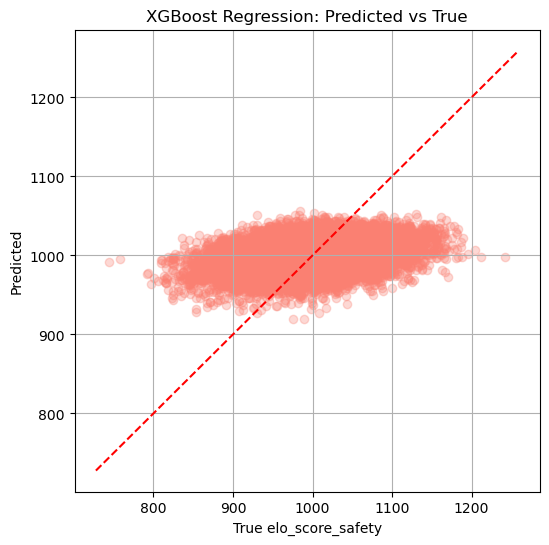

In [15]:
# 可视化预测结果 vs 实际值
plt.figure(figsize = (6,6))
plt.scatter(y_test,y_pred,alpha = 0.3, color = 'salmon')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # 对角线
plt.xlabel('True elo_score_safety')
plt.ylabel('Predicted')
plt.title('XGBoost Regression: Predicted vs True')
plt.grid(True)
plt.show()

#### 随机森林

In [16]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
# 定义参数网格
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],# 拆分内部节点所需的最小样本数
    'min_samples_leaf': [1, 2],# 叶节点所需的最小样本数
    'max_features': ['sqrt']
}

# 网格搜索
grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x1054b1b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Exception ignored in: <function ResourceTracker.__del__ at 0x10cd81b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  F

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2', verbose=1)

RMSE: 49.74
R² score: 0.1268


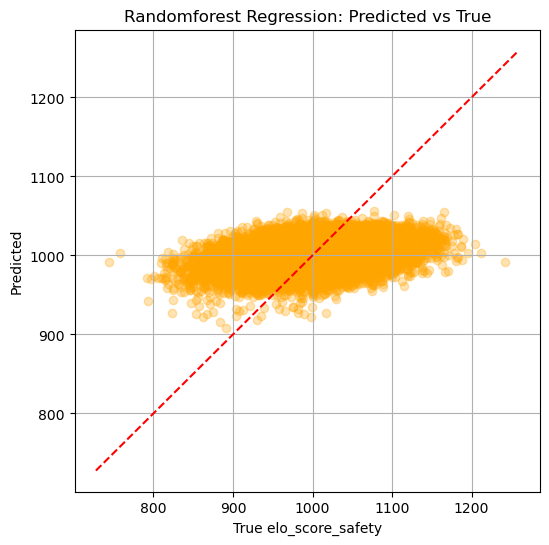

In [17]:
# 预测
best_model_rf = grid_search_rf.best_estimator_
y_pred = best_model_rf.predict(X_test_scaled)

# 评估
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

print("RMSE:", round(rmse, 2))
print("R² score:", round(r2, 4))

# 可视化预测结果 vs 实际值
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3, color='orange')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("True elo_score_safety")
plt.ylabel("Predicted")
plt.title("Randomforest Regression: Predicted vs True")
plt.grid(True)
plt.show()

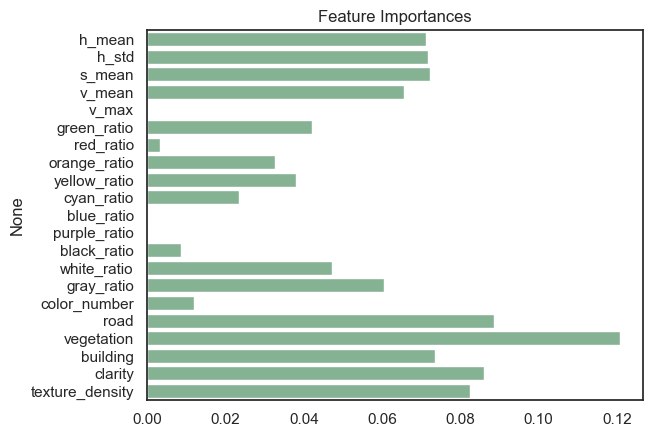

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 用模型内置的特征重要性（如 XGBoost / Random Forest）
# 查看哪些特征根本没用上（重要性 ≈ 0）
importances = best_model_rf.feature_importances_
features = X.columns

sns.set(palette = 'crest',style = 'white')
sns.barplot(x = importances,y = features)
plt.title('Feature Importances')
plt.show()

In [19]:
# 进行了筛选,缩减了feature的数目「其实也是一种降维」,进行训练

In [20]:
X_sel = data[[ 
    'h_mean', 'h_std', 's_mean', 'v_mean', 'green_ratio',
    'orange_ratio', 'yellow_ratio', 'cyan_ratio', 'white_ratio', 'gray_ratio', 
    'road', 'vegetation', 'building', 'clarity', 'texture_density'
]]

Fitting 5 folds for each of 24 candidates, totalling 120 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x10f57db20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Exception ignored in: <function ResourceTracker.__del__ at 0x1052e5b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  F

RMSE: 49.77
R² score: 0.1259


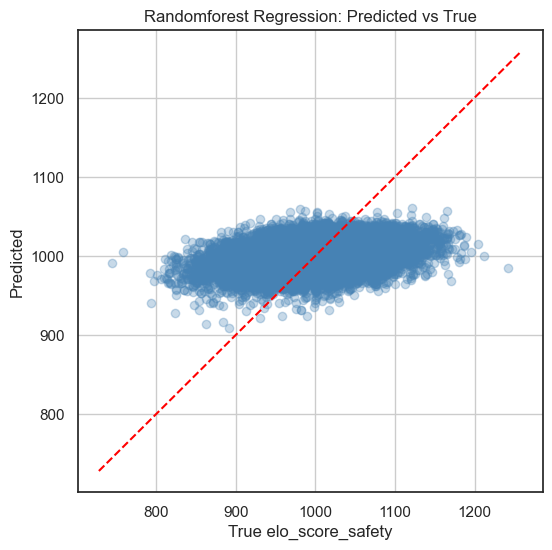

In [21]:
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(X_sel, y, test_size=0.2, random_state=42)

# 标准化（可选但推荐）
scaler = StandardScaler()
X_train_scaled_sel = scaler.fit_transform(X_train_sel)
X_test_scaled_sel = scaler.transform(X_test_sel)

rf = RandomForestRegressor(random_state=42)
# 定义参数网格
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

# 网格搜索
grid_search_rf_sel = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_rf_sel.fit(X_train_scaled_sel, y_train_sel)
best_model_rf_sel = grid_search_rf_sel.best_estimator_

y_pred_sel = best_model_rf_sel.predict(X_test_scaled_sel)

# 评估
rmse = np.sqrt(mean_squared_error(y_test_sel, y_pred_sel))
r2 = r2_score(y_test_sel, y_pred_sel)

print("RMSE:", round(rmse, 2))
print("R² score:", round(r2, 4))

# 可视化预测结果 vs 实际值
plt.figure(figsize=(6, 6))
plt.scatter(y_test_sel, y_pred_sel, alpha=0.3, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("True elo_score_safety")
plt.ylabel("Predicted")
plt.title("Randomforest Regression: Predicted vs True")
plt.grid(True)
plt.show()

### LassoCV 自动挑选特征

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv = 5,random_state = 42)
lasso.fit(X_scaled,y)

# 获取每个特征的系数
coef = lasso.coef_

# 输出被选中的特征
selected_features = X.columns[coef != 0]
print('被选中的特征:', list(selected_features))

# alpha的最优解
print('最优alpha:',lasso.alpha_)

被选中的特征: ['h_mean', 'h_std', 's_mean', 'green_ratio', 'red_ratio', 'orange_ratio', 'yellow_ratio', 'cyan_ratio', 'blue_ratio', 'purple_ratio', 'black_ratio', 'white_ratio', 'color_number', 'road', 'vegetation', 'building', 'clarity', 'texture_density']
最优alpha: 0.025439096354576203


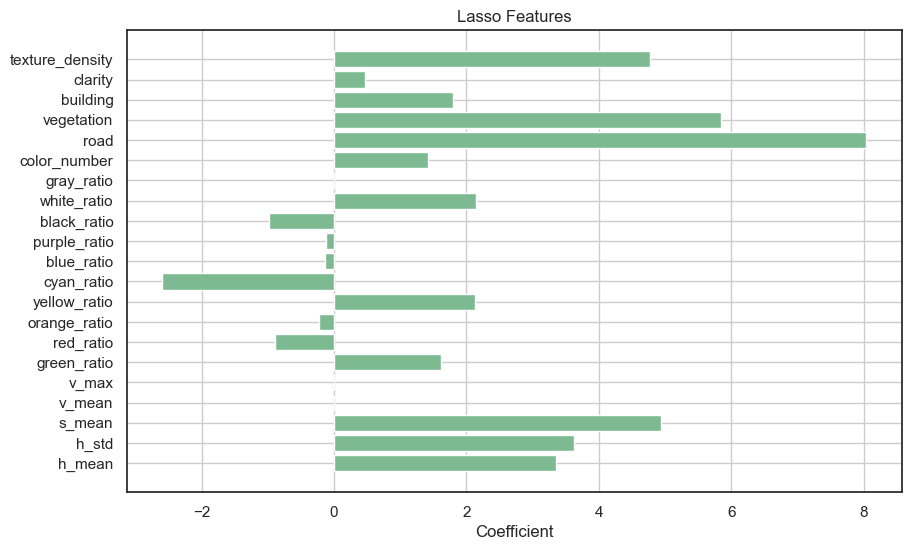

In [24]:
plt.figure(figsize = (10,6))
plt.barh(X.columns,coef)
plt.title('Lasso Features')
plt.xlabel('Coefficient')
plt.grid(True)
plt.show()

In [25]:
selected_features

Index(['h_mean', 'h_std', 's_mean', 'green_ratio', 'red_ratio', 'orange_ratio',
       'yellow_ratio', 'cyan_ratio', 'blue_ratio', 'purple_ratio',
       'black_ratio', 'white_ratio', 'color_number', 'road', 'vegetation',
       'building', 'clarity', 'texture_density'],
      dtype='object')

In [26]:
lasso_list = list(selected_features)
lasso_list

['h_mean',
 'h_std',
 's_mean',
 'green_ratio',
 'red_ratio',
 'orange_ratio',
 'yellow_ratio',
 'cyan_ratio',
 'blue_ratio',
 'purple_ratio',
 'black_ratio',
 'white_ratio',
 'color_number',
 'road',
 'vegetation',
 'building',
 'clarity',
 'texture_density']

In [27]:
# 从 data 数据集中选取 lasso_list 所指定的列，将选取的这些列的数据赋值给 X_lasso_sel

In [28]:
X_lasso_sel = data[lasso_list]

data[lasso_list] = data['h_mean','h_std','s_mean','green_ratio','red_ratio','orange_ratio','yellow_ratio','cyan_ratio','blue_ratio',
 'purple_ratio','black_ratio','white_ratio','color_number','road','vegetation','building','clarity','texture_density']

In [29]:
# 筛选出lasso之后coef不是0的重要特征

In [30]:
X_lasso_sel

,h_mean,h_std,s_mean,green_ratio,red_ratio,orange_ratio,yellow_ratio,cyan_ratio,blue_ratio,purple_ratio,black_ratio,white_ratio,color_number,road,vegetation,building,clarity,texture_density
0,59.777342,42.281507,43.972375,0.000000,0.0,0.327358,0.137242,0.037942,0.0,0.0,0.000000,0.000000,4,30.108643,8.288574,14.099121,1695.431309,0.109367
1,44.728267,37.648842,62.034000,0.000000,0.0,0.140300,0.686600,0.000000,0.0,0.0,0.000000,0.000000,3,11.358643,49.255371,1.159668,1793.139442,0.091800
2,52.645892,38.345215,70.778133,0.000000,0.0,0.000000,0.614258,0.244242,0.0,0.0,0.000000,0.141500,3,25.579834,27.362061,4.821777,3981.626890,0.171992
3,59.708800,44.573643,29.268692,0.000000,0.0,0.000000,0.108533,0.000000,0.0,0.0,0.000000,0.275108,3,31.072998,9.954834,26.251221,2593.127151,0.117633
4,46.192183,39.487293,49.982667,0.000000,0.0,0.000000,0.231792,0.000000,0.0,0.0,0.000000,0.092800,3,24.835205,19.970703,19.769287,2377.207408,0.151850
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110642,57.419067,41.494324,36.718183,0.268900,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.395100,3,15.924072,19.927979,7.598877,1246.722885,0.058967
110643,56.809767,41.339208,33.078917,0.000000,0.0,0.000000,0.182158,0.000000,0.0,0.0,0.000000,0.135758,3,34.967041,44.708252,12.976074,2796.564592,0.164558
110644,56.992183,41.434137,51.647583,0.000000,0.0,0.225533,0.000000,0.229575,0.0,0.0,0.231175,0.188975,5,14.666748,9.649658,37.860107,2384.432047,0.129942
110645,75.211575,42.740632,41.010842,0.187708,0.0,0.000000,0.153733,0.000000,0.0,0.0,0.000000,0.529733,4,18.249512,14.367676,0.061035,1108.899600,0.076642


In [31]:
def SelectBestRandomForest(X_sel,y):
    X_train_sel,X_test_sel,y_train_sel,y_test_sel = train_test_split(X_sel,y,test_size = 0.2,random_state = 42)
    
    # 标准化
    scaler = StandardScaler()
    X_train_scaled_sel = scaler.fit_transform(X_train_sel)
    X_test_scaled_sel = scaler.fit_transform(X_test_sel)

    # random forest regressor
    rf = RandomForestRegressor(random_state = 42)

    # grid search cv
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt']
    }

    grid_search_rf_sel = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        scoring='r2',
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid_search_rf_sel.fit(X_train_scaled_sel,y_train_sel)
    best_model_rf_sel = grid_search_rf_sel.best_estimator_

    y_pred_sel = best_model_rf_sel.predict(X_test_scaled_sel)

    # estimate
    rmse = np.sqrt(mean_squared_error(y_test_sel,y_pred_sel))
    r2 = r2_score(y_test_sel,y_pred_sel)

    print("RMSE:", round(rmse, 2))
    print("R² score:", round(r2, 4))

    return best_model_rf_sel,rmse,r2

In [32]:
best_model_rf_sel,rmse,r2 = SelectBestRandomForest(X_lasso_sel,y)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


Exception ignored in: <function ResourceTracker.__del__ at 0x108de1b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Exception ignored in: <function ResourceTracker.__del__ at 0x1070a1b20>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  F

RMSE: 49.79
R² score: 0.1251


### 提取图像特征 - 卷积神经网络

In [2]:
from torchvision import models,transforms
from PIL import Image
import torch
from torchvision.models import resnet50,ResNet50_Weights

In [3]:
### 加载预训练模型,去掉最后分类层
# 这些代码行使用 PyTorch 库和 torchvision 库来加载一个预训练的 ResNet-50 模型，并将其修改为特征提取器。

# 加载预训练权重是为了利用模型从 ImageNet 图像中学习到的通用视觉特征，这在迁移学习中非常常见
resnet = resnet50(weights = ResNet50_Weights.DEFAULT)
# resnet50(...): 这是一个 PyTorch/torchvision 函数，用于实例化 ResNet-50 模型。ResNet-50 是一种深度残差网络，有 50 个层，通常用于图像分类任务。
# weights = ResNet50_Weights.DEFAULT: 这一参数指定模型使用预训练权重
# ResNet50_Weights.DEFAULT 通常指向在 ImageNet 大规模图像数据集上训练得到的最新、性能最佳的 ResNet-50 权重。

# 移除 ResNet-50 的最后一层（通常是全连接分类层 fc），将模型转换为一个特征提取器。
# 这一行代码的作用是创建一个新的 resnet 模型，含了原始 ResNet-50 的所有层，除了最后的分类层。该模型将输出特征向量（在全连接层之前的特征图），而不是最终的类别概率。
resnet = torch.nn.Sequential(*list(resnet.children())[:-1]) # 去掉fc层
# resnet.children(): 这是一个 PyTorch nn.Module 的方法，它返回一个迭代器，包含模型 resnet 的直接子模块（或称“子层”）。
# 对于 ResNet-50 模型来说，这些子模块通常包括初始的卷积层、BatchNorm 层、最大池化层、四个残差块阶段以及最后的平均池化层和全连接层。
# list(...): 将子模块的迭代器转换为一个 Python 列表。
# [:-1]: 这是一个 Python 切片操作，它会从列表中移除最后一个元素。对于标准的 ResNet-50 模型，最后一个元素就是用于最终分类的全连接层 (fc)。
# *: 这是一个 Python 解包运算符 (unpacking operator)，它将列表中的所有模块作为单独的参数传递给 torch.nn.Sequential。
# torch.nn.Sequential(...): 这是一个 PyTorch 容器模块，它按照传入的顺序将一系列模块顺序连接起来。

# resnet.eval(): 这是一个 PyTorch 模型方法，用于将模型设置为评估（evaluation）模式。
# 在执行特征提取、验证或测试时，必须调用此方法，否则会导致不正确或不一致的结果
resnet.eval()
# 在评估模式下，某些在训练和推理时行为不同的模块会被固定下来，以确保推理结果的确定性和一致性：
# BatchNorm（批量归一化）层: 停止计算和更新其运行平均值和运行方差。它会使用训练过程中学到的全局统计量来对输入进行归一化。
# Dropout 层: 被禁用。在评估模式下，所有神经元都会被激活，不会随机丢弃。



### 图像预处理(尺寸,归一化)

preprocess = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize( # ImageNet 的标准化参数
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# transforms.Compose([...])
# 这是一个 PyTorch torchvision.transforms 模块提供的工具，它允许您将多个独立的图像变换操作按顺序组合成一个可调用的序列。
# 当您调用 preprocess(image) 时，图像将依次通过列表中的所有操作。

# transforms.Resize((224, 224))作用: 将输入图像的尺寸调整为固定的 224*224 像素。
# 原因: ResNet-50 等经典卷积神经网络（CNN）模型的输入层通常期望接收一个固定尺寸的图像，这个尺寸通常是 224*224

# transforms.ToTensor()作用: 将输入图像转换为 PyTorch Tensor（张量）格式。
# 细节:如果输入是 PIL 图像（或其他格式），它会将像素值从 [0, 255] 的整数范围缩放到 [0.0, 1.0] 的浮点数范围。
# 它还会改变图像的维度顺序，从 PIL 图像的 (H, W, C) (高, 宽, 通道) 格式转换为 PyTorch 约定使用的 (C, H, W) 格式。

# transforms.Normalize(...)作用: 对图像张量的每个通道（红、绿、蓝）进行标准化（Normalization）。
# 公式: 对于每个像素值 $v$，标准化后的值为 $v' = \frac{v - \text{mean}}{\text{std}}$。



### 读取图像并提取特征

img = Image.open('5185d53bfdc9f03fd5001493.jpg').convert('RGB') # Pillow打开图像,读进来的一般是BGR
input_tensor = preprocess(img).unsqueeze(0)  # [1, 3, 224, 224]

# preprocessing(img):作用: 调用前面定义的预处理序列 (transforms.Compose)，对 PIL 图像对象 img 执行以下操作：
# Resize: 调整到 224*224 像素。
# ToTensor: 转换为 $\frac{C \times H \times W}{(3 \times 224 \times 224)}$ 的 PyTorch 浮点张量，值域从 [0, 255] 变为 [0.0, 1.0]。
# Normalize: 使用 ImageNet 的均值和标准差进行标准化。
# 结果: 得到一个形状为 (3, 224, 224) 的张量。
    
# .unsqueeze(0):作用: 在张量的第 0 个维度（最前面）增加一个大小为 1 的新维度。
# 原因: 深度学习模型（如 ResNet-50）通常被设计为处理一批（Batch）图像，而不是单个图像。
# 即使您只输入一张图像，模型仍然期望输入张量的形状是 (B, C, H, W)，其中 B 是 Batch Size（批次大小）。
# 结果: 最终得到的 input_tensor 形状为 [1, 3, 224, 224]，其中 1 就是 Batch Size。

with torch.no_grad(): # 无梯度计算
    features = resnet(input_tensor) # shape: [1, 2048, 1, 1]
    features = features.view(-1).numpy() # shape: [2048] # 得到的 features 就是该图像的高维向量表示，可作为 X 输入模型中。

# features = resnet(input_tensor)resnet(...): 
# 这是将预处理后的图像张量 (input_tensor) 前向传递（Forward Pass）通过修改后的 ResNet-50 模型（已移除最后的分类层）。
# 处理过程:
# 1. input_tensor（形状 [1, 3, 224, 224]）进入 resnet 模型。
# 2. 数据依次通过卷积层、残差块、最大池化层等。
# 3. 数据到达模型的平均池化层（Global Average Pooling Layer）。
# 4. 平均池化层将空间维度 (H, W) 塌缩为 1*1，输出一个形状约为 [1, 2048, 1, 1] 的张量 (对于 ResNet-50)。
#    这个 2048 维向量就是图像的高级特征表示。
# 结果: features 是一个包含提取出的特征的 PyTorch 张量。

# features = features.view(-1).numpy()
# 将 PyTorch 张量转换为一个一维的 NumPy 数组，便于后续的数据处理和存储
# features.view(-1):
# view(...): 这是 PyTorch 中用于重塑（Reshape）张量的方法。
# -1: 作为一个参数，它告诉 PyTorch 自动计算出将张量展平为一维所需的总元素数量。
# 结果: 将形状为 [1, 2048, 1, 1] 的张量展平为形状为 [2048] 的一维张量。

features
    

array([0.        , 0.        , 0.04024127, ..., 0.        , 0.        ,
       0.00695946], dtype=float32)

In [4]:
def ResNet50Train(img_path):
    try:
        img = Image.open(img_path).convert('RGB')
        input_tensor = preprocess(img).unsqueeze(0)
        with torch.no_grad():
            features = resnet(input_tensor)
            features = features.view(-1).numpy()
        return features
    except Exception as e:
        print(f'Error processing {img_path}:{e}')
        return None

In [5]:
import pandas as pd
data = pd.read_csv('20251103.csv')

In [6]:
from tqdm import tqdm

all_features = []
filenames = []

for filename in tqdm(data['filename'].to_list()):
    image_path = f'/Users/zhaojunran/Documents/Python_Urban_Perception_and_Visual_Character/MIT_Place_Pulse_archive/gsv/final_photo_dataset/{filename}'
    features = ResNet50Train(img_path = image_path)
    if features is not None:
        all_features.append(features)
        filenames.append(filename)           

100%|█████████████████████████████████| 110647/110647 [2:51:47<00:00, 10.73it/s]


In [9]:
features_df = pd.DataFrame(all_features,columns = [f'feature{i}' for i in range(2048)])
features_df['filename'] = filenames
features_df

,feature0,feature1,feature2,feature3,feature4,feature5,feature6,feature7,feature8,feature9,...,feature2039,feature2040,feature2041,feature2042,feature2043,feature2044,feature2045,feature2046,feature2047,filename
0,0.000000,0.000000,0.000000,0.000000,0.000449,0.000000,0.000000,0.075439,0.000000,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000274,0.000000,0.000000,51415142fdc9f04926007f43.jpg
1,0.000000,0.005084,0.039826,0.000000,0.384426,0.000150,0.031166,0.336181,0.009652,0.0,...,0.000000,0.000000,0.000000,0.000000,0.077495,0.000000,0.000000,0.005432,0.000000,50f5ed9afdc9f065f0008e32.jpg
2,0.000000,0.001992,0.149342,0.000000,0.378925,0.000000,0.055309,0.234088,0.057883,0.0,...,0.104420,0.187439,0.000000,0.000000,0.012013,0.011617,0.150900,0.000000,0.053899,513e6050fdc9f0358700b395.jpg
3,0.000000,0.000000,0.018208,0.000000,0.287617,0.000000,0.000000,0.001222,0.016551,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50f5eb28fdc9f065f0008096.jpg
4,0.000000,0.000142,0.000000,0.000000,0.018920,0.000000,0.000000,0.000000,0.000000,0.0,...,0.000000,0.000000,0.000000,0.046857,0.000000,0.000000,0.000000,0.000000,0.000000,50f5ec32fdc9f065f00087a7.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110642,0.000000,0.000000,0.000000,0.000000,0.260367,0.000000,0.000000,0.000000,0.184744,0.0,...,0.000000,0.000000,0.000000,0.019664,0.050475,0.000000,0.000000,0.000000,0.026789,5140db1bfdc9f04926003e88.jpg
110643,0.000350,0.000000,0.000948,0.000000,0.291641,0.000000,0.003854,0.042232,0.007801,0.0,...,0.097376,0.038339,0.052415,0.000000,0.000000,0.023325,0.000000,0.000000,0.000000,513d9d13fdc9f03587007f59.jpg
110644,0.000000,0.000000,0.070729,0.000000,0.278268,0.000000,0.012590,0.116341,0.270673,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.015407,0.000000,0.000000,0.000000,513e6b92fdc9f0358700c04f.jpg
110645,0.001158,0.000000,0.036605,0.004311,0.236050,0.000000,0.000000,0.039981,0.000000,0.0,...,0.000000,0.000000,0.000000,0.001190,0.000000,0.000000,0.000000,0.000000,0.000000,513d586efdc9f035870032f5.jpg


In [ ]:
features_df.to_csv('features_image.csv')

In [10]:
data_matched = data.merge(features_df,on = 'filename',how = 'inner')

In [11]:
data_matched.head()

,Unnamed: 0.5,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,cluster_centers_rgb,color_ratios_raw,cluster_centers_hsv,matched_colors_raw,...,feature2038,feature2039,feature2040,feature2041,feature2042,feature2043,feature2044,feature2045,feature2046,feature2047
0,0,0,0,0,0,0,[[153 160 165]\n [ 22 80 129]\n [127 123 111]...,[0.34035833 0.03794167 0.32735833 0.1571 0...,"[array([103, 19, 165], dtype=uint8), array([1...","['gray', 'cyan', 'orange', 'gray', 'yellow']",...,0.000000,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000274,0.000000,0.000000
1,1,1,1,1,1,1,[[ 36 35 26]\n [171 174 177]\n [ 93 96 66]...,[0.27780833 0.1731 0.21171667 0.1403 0...,"[array([27, 71, 36], dtype=uint8), array([105,...","['yellow', 'gray', 'yellow', 'orange', 'yellow']",...,0.000000,0.00000,0.000000,0.0,0.000000,0.077495,0.000000,0.000000,0.005432,0.000000
2,2,2,2,2,2,2,[[153 148 121]\n [ 53 54 32]\n [214 215 209]...,[0.202775 0.20121667 0.1415 0.24424167 0...,"[array([ 25, 53, 153], dtype=uint8), array([ ...","['yellow', 'yellow', 'white', 'cyan', 'yellow']",...,0.021045,0.10442,0.187439,0.0,0.000000,0.012013,0.011617,0.150900,0.000000,0.053899
3,3,3,3,3,3,3,[[ 68 72 69]\n [204 205 204]\n [157 159 158]...,[0.24099167 0.27510833 0.28238333 0.09298333 0...,"[array([68, 14, 72], dtype=uint8), array([ 60,...","['gray', 'white', 'gray', 'gray', 'yellow']",...,0.038341,0.00000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,4,4,4,4,4,4,[[ 52 54 33]\n [143 140 133]\n [203 205 204]...,[0.23179167 0.2211 0.0928 0.12643333 0...,"[array([33, 99, 54], dtype=uint8), array([ 21,...","['yellow', 'gray', 'white', 'gray', 'gray']",...,0.007417,0.00000,0.000000,0.0,0.046857,0.000000,0.000000,0.000000,0.000000,0.000000


In [12]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 提取结构化特征 & 标签
features_cols = ['h_mean', 'h_std', 's_mean',  'green_ratio',
    'red_ratio', 'orange_ratio', 'yellow_ratio', 'cyan_ratio', 'black_ratio', 'white_ratio', 'gray_ratio', 
    'road', 'vegetation', 'building', 'clarity', 'texture_density']
structured_features = data_matched[features_cols].values
labels = data_matched['elo_score_safety'].values

# 标准化
scaler_tab = StandardScaler()
scaler_img = StandardScaler()
structure_scaled = scaler_tab.fit_transform(structured_features)
image_scaled = scaler_img.fit_transform(all_features)

# 拼接
X = np.concatenate([image_scaled,structure_scaled],axis = 1)
X = np.clip(X,-10,10)
y = labels

In [13]:
import numpy as np

print("NaN in X:", np.isnan(X).sum())
print("inf in X:", np.isinf(X).sum())
print("Max per column:\n", X.max(axis=0))
print("Min per column:\n", X.min(axis=0))
means = X.mean(axis=0)
stds = X.std(axis=0)
print("Feature stds:\n", stds)

NaN in X: 0
inf in X: 0
Max per column:
 [10.         10.         10.         ...  5.35679646 10.
  6.00011915]
Min per column:
 [-0.25309685 -0.34472698 -0.42134744 ... -0.84159555 -1.74565332
 -2.54418337]
Feature stds:
 [0.87936538 0.94180038 0.9472144  ... 1.         0.99968462 1.        ]


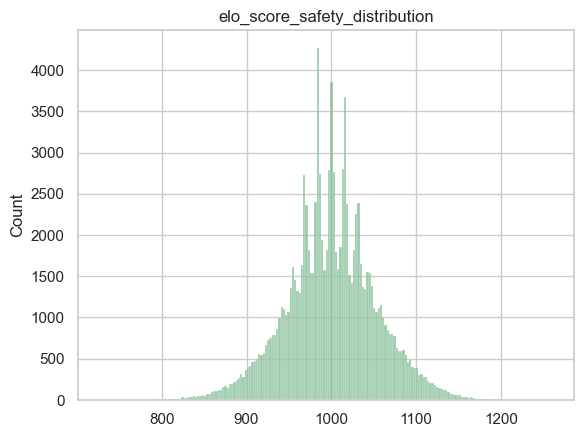

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(palette = 'crest',style = 'whitegrid')
sns.histplot(y,kde = False)
plt.title('elo_score_safety_distribution')
plt.show()

In [18]:
from xgboost import XGBRegressor

# 所有feature的名字list,之前的色彩饱和度以及CNN分析出来的2048维features
feature_names = [f'f{i}' for i in range(2048)] + features_cols
# features_cols = ['h_mean', 'h_std', 's_mean',  'green_ratio',
#     'red_ratio', 'orange_ratio', 'yellow_ratio', 'cyan_ratio', 'black_ratio', 'white_ratio', 'gray_ratio', 
#     'road', 'vegetation', 'building', 'clarity', 'texture_density']

# machine learning
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state = 42)
model = XGBRegressor(
    n_estimators = 200,
    max_depth = 6,
    learning_rate = 0.05
)
model.fit(X,y)
model.get_booster().feature_names = feature_names
# .get_booster(): 这是一个方法，用于从 XGBoost Python 包装器对象中提取底层的 C++ Booster 对象。Booster 是 XGBoost 算法的核心实现，负责实际的树构建和预测。
# .feature_names: 这是 Booster 对象的一个属性，用于存储输入特征的名称（例如，['age', 'salary', 'city']）

print("R²:", model.score(X_test, y_test))
# 对于 回归 模型（如 XGBRegressor），score 方法默认返回 $R^2$ 评分（决定系数）。
# 对于 分类 模型（如 XGBClassifier），score 方法默认返回准确率（Accuracy）。

R²: 0.36739321562807237


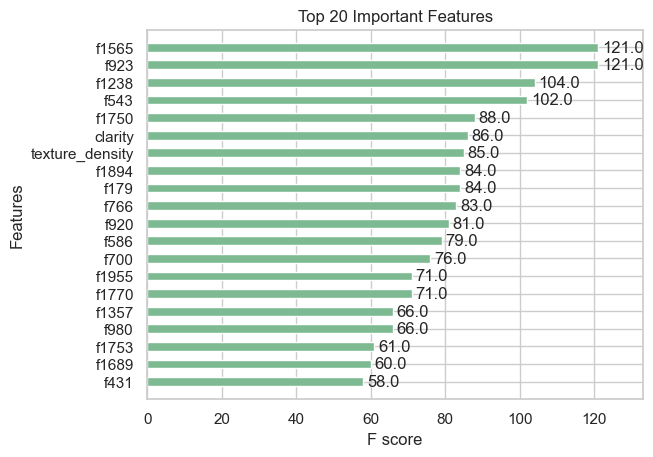

In [20]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model, max_num_features=20, height=0.5)
plt.title("Top 20 Important Features")
plt.show()

In [21]:
import shap

explainer = shap.Explainer(model)
shap_values = explainer(X)

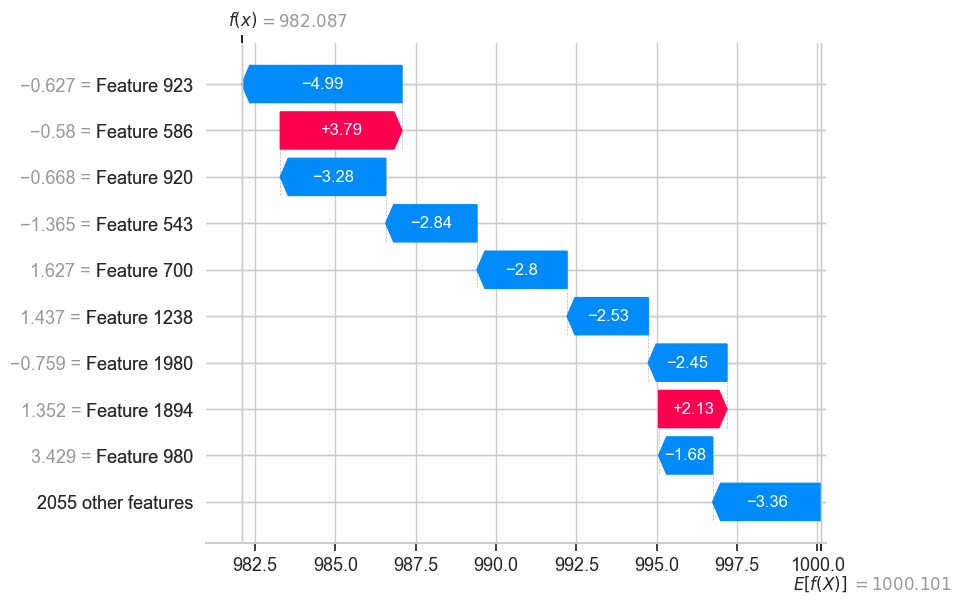

In [22]:
# visualize
shap.plots.waterfall(shap_values[0])

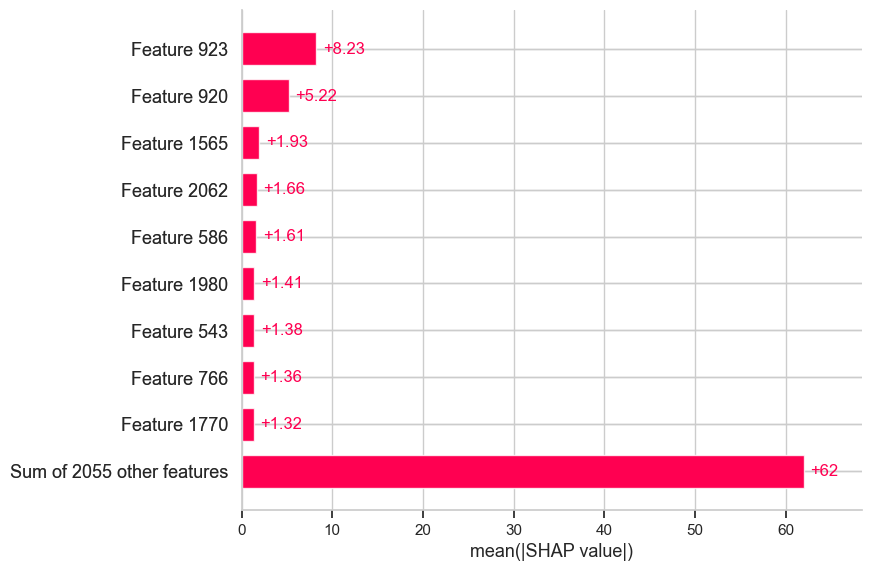

In [23]:
# 全剧贡献特征
shap.plots.bar(shap_values)

In [24]:
from torch.utils.data import TensorDataset,DataLoader
# torch.utils.data: 这是 PyTorch 提供的用于处理数据的实用工具模块
# TensorDataset: 用于封装 PyTorch 张量（Tensors）的 Dataset 类。它将您提供的 X（特征）和 y（标签）张量捆绑在一起，使得您可以同时访问输入数据及其对应的标签。
# DataLoader: 用于从 Dataset 中加载数据的迭代器。它负责处理数据加载的几个关键方面，包括批量处理 (Batching)、数据打乱 (Shuffling)，以及可选的多进程加载 (Multi-processing)。

import torch

# 创建特征张量
X_tensor = torch.tensor(X,dtype = torch.float32)
# 将原始数据 X（通常是 NumPy 数组或列表）转换为 PyTorch 的张量。指定数据类型为 torch.float32 (32位浮点数)，这是深度学习中常用的数据类型。

# 创建标签张量
y_tensor = torch.tensor(y,dtype = torch.float32)
# 将原始标签 y 转换为 PyTorch 张量。

# 创建数据集
dataset = TensorDataset(X_tensor,y_tensor)
# 将特征张量和标签张量打包成一个 TensorDataset 对象。现在，这个 dataset 对象可以迭代地返回 (X_sample, y_sample) 对。

# 创建数据加载器
dataloader = DataLoader(dataset,batch_size = 32,shuffle = True)
# 基于上述 dataset 创建一个 DataLoader 实例。这是最重要的步骤：
# batch_size = 32: 指定每次迭代时返回 32 个样本。在训练时，这决定了模型权重更新的频率和样本数量。
# shuffle = True: 在每个训练周期 (epoch) 开始时，对数据进行随机打乱，以减少模型学习到数据顺序的可能性，提高模型的泛化能力。

In [27]:
import torch
import torch.nn as nn

# CombinedFeatureRegressor 是一个设计合理的深度神经网络模型，适用于处理多维特征的回归预测问题
class CombinedFeatureRegressor(nn.Module): # 该模型继承自 torch.nn.Module，这是所有 PyTorch 神经网络模块的基类
    def __init__(self,input_dim): 
        # input_dim	参数	输入特征的维度，决定了第一层 nn.Linear 的输入大小。
        
        super().__init__() # 调用父类初始化
        self.net = nn.Sequential( # 序列容器 : 将多个模块（层）按顺序组合成一个单一的、易于管理的前馈网络。

            # 1.输入层：input_dim -> 512
            nn.Linear(input_dim, 512), # 全连接层 : 执行线性变换 y = xW^T + b。例如，nn.Linear(input_dim, 512) 将输入维度映射到 512 个输出维度。最后一层输出维度为 1，表明这是一个单值回归任务。
            nn.BatchNorm1d(512), # 批量归一化层 : 对上一层输出的激活值进行归一化。这有助于稳定和加速训练，尤其是在较深的网络中。
            nn.ReLU(), # 激活函数 : 修正线性单元（Rectified Linear Unit）。它引入了非线性，允许网络学习复杂的模式。f(x) = max(0, x)。
            nn.Dropout(0.3), # 随机失活层 : 在训练期间，随机地将 $30\%$ 的输入单元设置为 $0$。这是一种正则化技术，用于防止模型过拟合。

            # 2.隐藏层 1：512 -> 256
            nn.Linear(512, 256), # 全连接层
            nn.BatchNorm1d(256), # 批量归一化层
            nn.ReLU(), # 激活函数
            nn.Dropout(0.3), # 随机失活层

            # 3.隐藏层 2：256 -> 64
            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            # 4.输出层：64 -> 1 (无激活函数，用于回归)
            nn.Linear(64, 1)
        )

    def forward(self, x): # forward (前向传播) 方法
        return self.net(x).squeeze()
        # self.net(x): 将输入数据 x 依次通过在 __init__ 中定义的序列网络 self.net
        # .squeeze(): 这是一个重要的操作。nn.Linear(64, 1) 的输出形状通常是 (batch_size, 1)。.squeeze() 函数会移除所有大小为 1 的维度。
        #             在这个上下文中，它将形状 (batch_size, 1) 变为 (batch_size)，这在计算回归任务的损失（如均方误差 MSE）时通常更方便和必要

In [28]:
# 确保模型和数据能够在最快的可用硬件（通常是 GPU）上运行，以加速训练过程
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 模型初始化与设备转移
model = CombinedFeatureRegressor(input_dim=X.shape[1]).to(device)
# 创建模型实例，并将其放置在与数据相同的设备上。在 PyTorch 中，模型和用于训练它的数据必须位于同一设备上，否则运行时会报错

In [29]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

for epoch in range(5):
    model.train()
    total_loss = 0
    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        output = model(X_batch)
        loss = criterion(output, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} - Loss: {total_loss / len(dataloader):.4f}")

Epoch 1 - Loss: 982098.7368
Epoch 2 - Loss: 911618.1878
Epoch 3 - Loss: 808247.5394
Epoch 4 - Loss: 682784.4886
Epoch 5 - Loss: 545080.2391


In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in dataloader:  # 用 test 或 validation dataloader
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        preds = model(X_batch)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# 转为 numpy 数组
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 计算指标
mse = mean_squared_error(all_labels, all_preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_labels, all_preds)
r2 = r2_score(all_labels, all_preds)

print(f"RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

RMSE: 696.5836, MAE: 689.0424, R²: -172.7454
